In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# CONFIGURATION
# ============================================================

PROJECT_ROOT = Path.cwd().parents[1]

METADATA_PATH = (
    PROJECT_ROOT /
    "reports" /
    "results" /
    "disease_final_metadata.csv"
)

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

RANDOM_STATE = 42

EPOCHS = 10


# ============================================================
# LOAD METADATA
# ============================================================

disease_df = pd.read_csv(
    METADATA_PATH
)


print("Metadata loaded successfully.")

print(
    f"Total images: {len(disease_df)}"
)

print(
    f"Datasets: {disease_df['Dataset'].nunique()}"
)

print(
    f"Classes: {disease_df['Class'].nunique()}"
)

print()

print(
    disease_df.head()
)

Metadata loaded successfully.
Total images: 112380
Datasets: 13
Classes: 135

                                                Path     Dataset  \
0  C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\py...  Watermelon   
1  C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\py...  Watermelon   
2  C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\py...  Watermelon   
3  C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\py...  Watermelon   
4  C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\py...  Watermelon   

          Class  Split  Label  
0  Mosaic_Virus  train      3  
1  Mosaic_Virus  train      3  
2   Anthracnose  train      0  
3  Downy_Mildew  train      1  
4  Mosaic_Virus  train      3  


In [2]:
DATASET_NAME = "mango"

dataset_df = disease_df[
    disease_df["Dataset"] == DATASET_NAME
].copy()


# Separate splits
train_df = dataset_df[
    dataset_df["Split"] == "train"
].copy()

val_df = dataset_df[
    dataset_df["Split"] == "val"
].copy()

test_df = dataset_df[
    dataset_df["Split"] == "test"
].copy()


# Get class names
class_names = sorted(
    dataset_df["Class"].unique()
)

NUM_CLASSES = len(class_names)


print("=" * 60)
print(f"Dataset: {DATASET_NAME}")
print("=" * 60)

print(f"Number of classes : {NUM_CLASSES}")
print(f"Training images   : {len(train_df)}")
print(f"Validation images : {len(val_df)}")
print(f"Testing images    : {len(test_df)}")

print("\nClasses:")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Dataset: mango
Number of classes : 6
Training images   : 1190
Validation images : 255
Testing images    : 255

Classes:
0: Alternaria
1: Anthracnose
2: Black Mould Rot
3: Healthy
4: Stem and Rot
5: Stem end Rot


In [3]:
# ============================================================
# IMAGE DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    """
    Load, decode, resize and normalize an image.
    """

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def create_dataset(
    dataframe,
    shuffle=False
):
    """
    Create TensorFlow dataset from dataframe.
    """

    paths = dataframe["Path"].values

    labels = dataframe["Label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_dataset = create_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)


print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [4]:
# ============================================================
# DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),

        tf.keras.layers.RandomRotation(
            0.10
        ),

        tf.keras.layers.RandomZoom(
            0.10
        ),

        tf.keras.layers.RandomContrast(
            0.10
        )
    ],
    name="data_augmentation"
)


print("Data augmentation configured.")

Data augmentation configured.


In [5]:
# ============================================================
# MOBILENETV2 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Load pretrained MobileNetV2
# ------------------------------------------------------------

base_model = MobileNetV2(
    input_shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    ),
    include_top=False,
    weights="imagenet"
)


# ------------------------------------------------------------
# Freeze pretrained layers
# ------------------------------------------------------------

base_model.trainable = False


# ------------------------------------------------------------
# Build classification model
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    )
)


# Data augmentation
x = data_augmentation(inputs)


# MobileNetV2 feature extraction
x = base_model(
    x,
    training=False
)


# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.3
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Disease_Detection"
)


# ------------------------------------------------------------
# Compile model
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "MobileNetV2_Disease_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# ============================================================
# MODEL CONFIGURATION CHECK
# ============================================================

print("=" * 60)
print("MODEL CONFIGURATION")
print("=" * 60)

print(f"Model name       : {model.name}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Input size       : {IMAGE_SIZE}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Epochs           : {EPOCHS}")

print(
    f"Trainable params : "
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print(
    f"Non-trainable params : "
    f"{sum(np.prod(v.shape) for v in model.non_trainable_weights):,}"
)

MODEL CONFIGURATION
Model name       : MobileNetV2_Disease_Detection
Number of classes: 6
Input size       : (224, 224)
Batch size       : 32
Epochs           : 10
Trainable params : 7,686
Non-trainable params : 2,257,984


In [7]:
# ============================================================
# TRAINING CALLBACKS
# ============================================================

MODEL_DIR = (
    PROJECT_ROOT /
    "models" /
    "disease"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BEST_MODEL_PATH = (
    MODEL_DIR /
    f"{DATASET_NAME}_mobilenetv2_best.keras"
)


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


print("Training callbacks configured.")
print(f"Best model will be saved to:\n{BEST_MODEL_PATH}")

Training callbacks configured.
Best model will be saved to:
c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_best.keras


In [8]:
# ============================================================
# TRAIN MOBILENETV2
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/10


c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.4370 - loss: 1.5016
Epoch 1: val_accuracy improved from None to 0.61569, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_best.keras

Epoch 1: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 851ms/step - accuracy: 0.4370 - loss: 1.5016 - val_accuracy: 0.6157 - val_loss: 0.9422 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.6622 - loss: 0.9108
Epoch 2: val_accuracy improved from 0.61569 to 0.76078, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_best.keras

Epoch 2: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistan

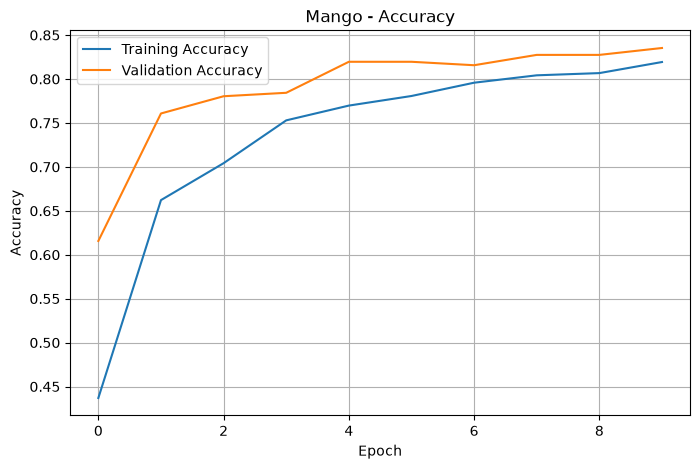

In [9]:
# ============================================================
# TRAINING AND VALIDATION PERFORMANCE
# ============================================================

history_df = pd.DataFrame(
    history.history
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    f"{DATASET_NAME.title()} - Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

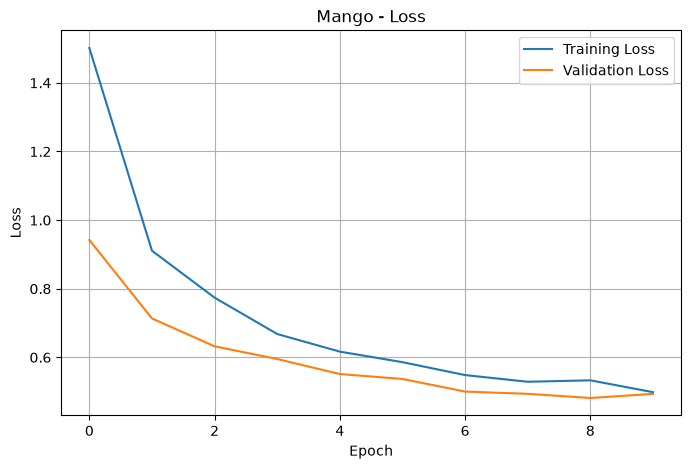

In [10]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.title(
    f"{DATASET_NAME.title()} - Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [11]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)


print(
    f"Best model loaded from:\n{BEST_MODEL_PATH}"
)


# ============================================================
# TEST SET EVALUATION
# ============================================================

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)


print()
print("=" * 60)
print("TEST PERFORMANCE")
print("=" * 60)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

Best model loaded from:
c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step - accuracy: 0.8235 - loss: 0.5309

TEST PERFORMANCE
Test Loss     : 0.5309
Test Accuracy : 0.8235
Test Accuracy : 82.35%


In [12]:
# ============================================================
# GENERATE TEST SET PREDICTIONS
# ============================================================

y_true = []
y_pred = []


for images, labels in test_dataset:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)


print("Predictions generated successfully.")

print(
    f"True labels      : {len(y_true)}"
)

print(
    f"Predicted labels : {len(y_pred)}"
)

Predictions generated successfully.
True labels      : 255
Predicted labels : 255


In [13]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("MANGO - CLASSIFICATION REPORT")
print("=" * 70)

classification_report_result = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(
    classification_report_result
)

MANGO - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

     Alternaria     0.6250    0.8824    0.7317        51
    Anthracnose     1.0000    0.5897    0.7419        39
Black Mould Rot     0.7407    0.7273    0.7339        55
        Healthy     0.9841    1.0000    0.9920        62
   Stem and Rot     0.9167    0.9565    0.9362        23
   Stem end Rot     0.9474    0.7200    0.8182        25

       accuracy                         0.8235       255
      macro avg     0.8690    0.8126    0.8257       255
   weighted avg     0.8525    0.8235    0.8240       255



In [14]:
# ============================================================
# CLASSIFICATION METRICS DATAFRAME
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)


metrics_df = pd.DataFrame(
    report_dict
).transpose()


metrics_df

,precision,recall,f1-score,support
Alternaria,0.625000,0.882353,0.731707,51.000000
Anthracnose,1.000000,0.589744,0.741935,39.000000
Black Mould Rot,0.740741,0.727273,0.733945,55.000000
Healthy,0.984127,1.000000,0.992000,62.000000
Stem and Rot,0.916667,0.956522,0.936170,23.000000
Stem end Rot,0.947368,0.720000,0.818182,25.000000
accuracy,0.823529,0.823529,0.823529,0.823529
macro avg,0.868984,0.812648,0.825657,255.000000
weighted avg,0.852546,0.823529,0.823961,255.000000


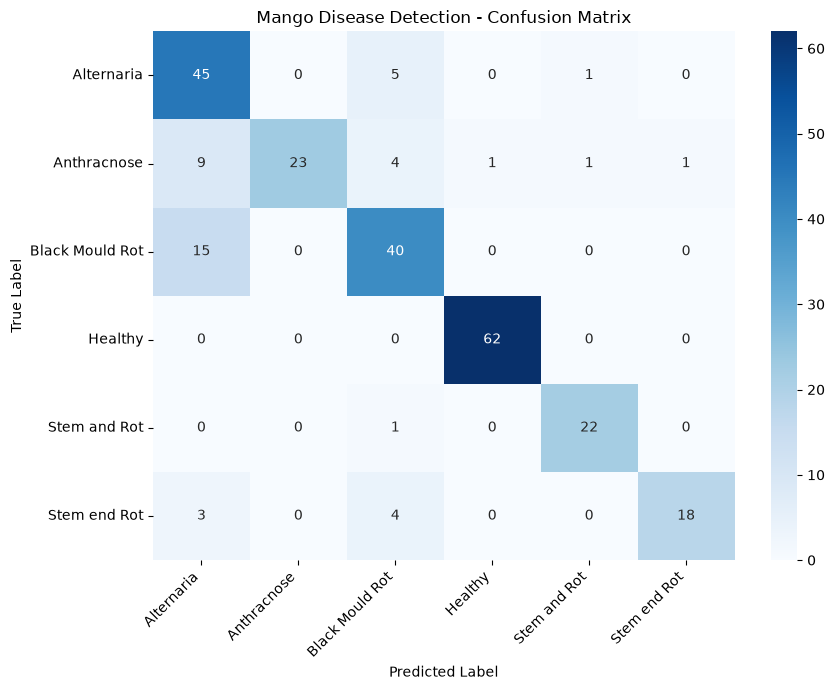

In [17]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title(
    "Mango Disease Detection - Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [16]:
# ============================================================
# OVERALL PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("=" * 60)
print("MANGO MODEL PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy  : {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1-score  : {f1:.4f}"
)

print("=" * 60)

MANGO MODEL PERFORMANCE
Accuracy  : 0.8235 (82.35%)
Precision : 0.8525
Recall    : 0.8235
F1-score  : 0.8240


In [18]:
# ============================================================
# MOBILENETV2 FINE-TUNING
# ============================================================

# Unfreeze the MobileNetV2 base model
base_model.trainable = True


# Freeze the earlier layers and fine-tune only
# the deeper feature-extraction layers.
#
# MobileNetV2 has 155 layers in total.
# We keep most of them frozen.

for layer in base_model.layers[:-30]:
    layer.trainable = False


# Recompile with a much smaller learning rate.
#
# A small learning rate is important during fine-tuning
# so that pretrained ImageNet features are not destroyed.

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("=" * 60)
print("MOBILENETV2 FINE-TUNING CONFIGURATION")
print("=" * 60)

print(
    f"Total layers     : {len(base_model.layers)}"
)

print(
    f"Trainable layers : "
    f"{sum(layer.trainable for layer in base_model.layers)}"
)

print(
    f"Learning rate    : 1e-5"
)

print("=" * 60)

MOBILENETV2 FINE-TUNING CONFIGURATION
Total layers     : 154
Trainable layers : 30
Learning rate    : 1e-5


In [19]:
# ============================================================
# FINE-TUNING CALLBACKS
# ============================================================

FINE_TUNED_MODEL_PATH = (
    MODEL_DIR /
    f"{DATASET_NAME}_mobilenetv2_finetuned_best.keras"
)


fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=FINE_TUNED_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)


fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


print(
    f"Fine-tuned model will be saved to:\n"
    f"{FINE_TUNED_MODEL_PATH}"
)

Fine-tuned model will be saved to:
c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_finetuned_best.keras


In [20]:
# ============================================================
# FINE-TUNE MOBILENETV2
# ============================================================

FINE_TUNE_EPOCHS = 10


fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    verbose=1
)

Epoch 1/10


c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.5042 - loss: 1.4726
Epoch 1: val_accuracy improved from None to 0.83137, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_mobilenetv2_finetuned_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 919ms/step - accuracy: 0.5042 - loss: 1.4726 - val_accuracy: 0.8314 - val_loss: 0.5029 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.6261 - loss: 1.0908
Epoch 2: val_accuracy did not improve from 0.83137
38/38 ━━━━━━━━━━━━━━━━━━━━ 25s 661ms/step - accuracy: 0.6261 - loss: 1.0908 - val_accuracy: 0.8078 - val_loss: 0.5245 - learning_rate: 1.0000e-05
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.7084 - loss: 0.8275
Epoch 3: val_accurac

In [21]:
# ============================================================
# LOAD BEST FINE-TUNED MODEL
# ============================================================

fine_tuned_model = tf.keras.models.load_model(
    FINE_TUNED_MODEL_PATH
)


# ============================================================
# TEST EVALUATION
# ============================================================

fine_tuned_test_loss, fine_tuned_test_accuracy = (
    fine_tuned_model.evaluate(
        test_dataset,
        verbose=1
    )
)


print("=" * 60)
print("FINE-TUNED MOBILENETV2 - MANGO")
print("=" * 60)

print(
    f"Test Loss     : {fine_tuned_test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{fine_tuned_test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{fine_tuned_test_accuracy * 100:.2f}%"
)

print("=" * 60)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 448ms/step - accuracy: 0.8314 - loss: 0.5089
FINE-TUNED MOBILENETV2 - MANGO
Test Loss     : 0.5089
Test Accuracy : 0.8314
Test Accuracy : 83.14%


In [27]:
# ============================================================
# EFFICIENTNETB0 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras.applications import EfficientNetB0


# ------------------------------------------------------------
# Load pretrained EfficientNetB0
# ------------------------------------------------------------

efficientnet_base = EfficientNetB0(
    input_shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    ),
    include_top=False,
    weights="imagenet"
)


# Freeze pretrained layers
efficientnet_base.trainable = False


# ------------------------------------------------------------
# Build EfficientNetB0 model
# ------------------------------------------------------------

efficientnet_inputs = layers.Input(
    shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    )
)


# Data augmentation
x = data_augmentation(
    efficientnet_inputs
)


# ------------------------------------------------------------
# IMPORTANT:
# Our dataset is normalized to [0, 1].
#
# EfficientNetB0 includes its own Rescaling layer
# that expects image values in the [0, 255] range.
#
# Therefore, convert [0, 1] back to [0, 255]
# before passing images to EfficientNetB0.
# ------------------------------------------------------------

x = layers.Rescaling(
    scale=255.0
)(x)


# Feature extraction
x = efficientnet_base(
    x,
    training=False
)


# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.3
)(x)

efficientnet_outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


efficientnet_model = models.Model(
    inputs=efficientnet_inputs,
    outputs=efficientnet_outputs,
    name="EfficientNetB0_Disease_Detection"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("EfficientNetB0 model created successfully.")

efficientnet_model.summary()

EfficientNetB0 model created successfully.


Model: "EfficientNetB0_Disease_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [28]:
# ============================================================
# EFFICIENTNETB0 TRAINING
# ============================================================

EFFICIENTNET_MODEL_PATH = (
    MODEL_DIR /
    f"{DATASET_NAME}_efficientnetb0_best.keras"
)


efficientnet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=EFFICIENTNET_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


efficientnet_history = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=efficientnet_callbacks,
    verbose=1
)

Epoch 1/10


c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5092 - loss: 1.3153
Epoch 1: val_accuracy improved from None to 0.71373, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_efficientnetb0_best.keras

Epoch 1: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_efficientnetb0_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 755ms/step - accuracy: 0.5092 - loss: 1.3153 - val_accuracy: 0.7137 - val_loss: 0.9255 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.7092 - loss: 0.8522
Epoch 2: val_accuracy improved from 0.71373 to 0.77647, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_efficientnetb0_best.keras

Epoch 2: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture

In [29]:
# ============================================================
# CORRECTED EFFICIENTNETB0 TEST EVALUATION
# ============================================================

best_efficientnet = tf.keras.models.load_model(
    EFFICIENTNET_MODEL_PATH
)


efficientnet_test_loss, efficientnet_test_accuracy = (
    best_efficientnet.evaluate(
        test_dataset,
        verbose=1
    )
)


print("=" * 60)
print("EFFICIENTNETB0 - MANGO")
print("=" * 60)

print(
    f"Test Loss     : {efficientnet_test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{efficientnet_test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{efficientnet_test_accuracy * 100:.2f}%"
)

print("=" * 60)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 489ms/step - accuracy: 0.8235 - loss: 0.5138
EFFICIENTNETB0 - MANGO
Test Loss     : 0.5138
Test Accuracy : 0.8235
Test Accuracy : 82.35%


In [30]:
# ============================================================
# RESNET50 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


# ------------------------------------------------------------
# Load pretrained ResNet50
# ------------------------------------------------------------

resnet_base = ResNet50(
    input_shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    ),
    include_top=False,
    weights="imagenet"
)

resnet_base.trainable = False


# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

resnet_inputs = layers.Input(
    shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    )
)


# Data augmentation
x = data_augmentation(
    resnet_inputs
)


# Our pipeline provides [0, 1].
# ResNet50 preprocessing expects [0, 255].
x = layers.Rescaling(
    scale=255.0
)(x)


# ResNet50 ImageNet preprocessing
x = layers.Lambda(
    preprocess_input
)(x)


# Feature extraction
x = resnet_base(
    x,
    training=False
)


# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.3
)(x)

resnet_outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


resnet_model = models.Model(
    inputs=resnet_inputs,
    outputs=resnet_outputs,
    name="ResNet50_Disease_Detection"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("ResNet50 model created successfully.")

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step

ResNet50 model created successfully.


Model: "ResNet50_Disease_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
# ============================================================
# RESNET50 TRAINING
# ============================================================

RESNET_MODEL_PATH = (
    MODEL_DIR /
    f"{DATASET_NAME}_resnet50_best.keras"
)


resnet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=RESNET_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


resnet_history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=resnet_callbacks,
    verbose=1
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.5176 - loss: 1.2781
Epoch 1: val_accuracy improved from None to 0.75294, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_best.keras

Epoch 1: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5176 - loss: 1.2781 - val_accuracy: 0.7529 - val_loss: 0.6845 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.7294 - loss: 0.7135
Epoch 2: val_accuracy improved from 0.75294 to 0.81569, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_best.keras

Epoch 2: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant

In [33]:
# ============================================================
# RESNET50 TEST EVALUATION
# ============================================================

from tensorflow.keras.applications.resnet50 import preprocess_input


best_resnet = tf.keras.models.load_model(
    RESNET_MODEL_PATH,
    custom_objects={
        "preprocess_input": preprocess_input
    }
)


resnet_test_loss, resnet_test_accuracy = (
    best_resnet.evaluate(
        test_dataset,
        verbose=1
    )
)


print("=" * 60)
print("RESNET50 - MANGO")
print("=" * 60)

print(
    f"Test Loss     : {resnet_test_loss:.4f}"
)

print(
    f"Test Accuracy : {resnet_test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{resnet_test_accuracy * 100:.2f}%"
)

print("=" * 60)

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 918ms/step - accuracy: 0.8706 - loss: 0.3585
RESNET50 - MANGO
Test Loss     : 0.3585
Test Accuracy : 0.8706
Test Accuracy : 87.06%


In [34]:
# ============================================================
# MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "MobileNetV2 Baseline",
        "MobileNetV2 Fine-Tuned",
        "EfficientNetB0",
        "ResNet50"
    ],

    "Test Accuracy": [
        test_accuracy,
        fine_tuned_test_accuracy,
        efficientnet_test_accuracy,
        resnet_test_accuracy
    ]
})


model_comparison["Test Accuracy (%)"] = (
    model_comparison["Test Accuracy"] * 100
)


model_comparison = model_comparison.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)


model_comparison

,Model,Test Accuracy,Test Accuracy (%)
0,ResNet50,0.870588,87.058824
1,MobileNetV2 Fine-Tuned,0.831373,83.137256
2,MobileNetV2 Baseline,0.823529,82.352942
3,EfficientNetB0,0.823529,82.352942


In [35]:
# ============================================================
# RESNET50 FINE-TUNING
# ============================================================

# Unfreeze the ResNet50 base
resnet_base.trainable = True


# Keep the earlier layers frozen.
# Fine-tune only the deeper layers.

for layer in resnet_base.layers[:-30]:
    layer.trainable = False


# Recompile with a small learning rate

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("=" * 60)
print("RESNET50 FINE-TUNING CONFIGURATION")
print("=" * 60)

print(
    f"Total layers     : {len(resnet_base.layers)}"
)

print(
    f"Trainable layers : "
    f"{sum(layer.trainable for layer in resnet_base.layers)}"
)

print(
    "Learning rate    : 1e-5"
)

print("=" * 60)

RESNET50 FINE-TUNING CONFIGURATION
Total layers     : 175
Trainable layers : 30
Learning rate    : 1e-5


In [36]:
# ============================================================
# RESNET50 FINE-TUNING
# ============================================================

RESNET_FINETUNED_PATH = (
    MODEL_DIR /
    f"{DATASET_NAME}_resnet50_finetuned_best.keras"
)


resnet_finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=RESNET_FINETUNED_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]


resnet_finetune_history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=resnet_finetune_callbacks,
    verbose=1
)

Epoch 1/10


c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8387 - loss: 0.4506
Epoch 1: val_accuracy improved from None to 0.88627, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_finetuned_best.keras

Epoch 1: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_finetuned_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8387 - loss: 0.4506 - val_accuracy: 0.8863 - val_loss: 0.3068 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8723 - loss: 0.3509
Epoch 2: val_accuracy improved from 0.88627 to 0.89412, saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\models\disease\mango_resnet50_finetuned_best.keras

Epoch 2: finished saving model to c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggri

In [37]:
# ============================================================
# RESNET50 FINE-TUNED TEST EVALUATION
# ============================================================

best_resnet_finetuned = tf.keras.models.load_model(
    RESNET_FINETUNED_PATH,
    custom_objects={
        "preprocess_input": preprocess_input
    }
)


resnet_ft_loss, resnet_ft_accuracy = (
    best_resnet_finetuned.evaluate(
        test_dataset,
        verbose=1
    )
)


print("=" * 60)
print("RESNET50 FINE-TUNED - MANGO")
print("=" * 60)

print(
    f"Test Loss     : {resnet_ft_loss:.4f}"
)

print(
    f"Test Accuracy : {resnet_ft_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{resnet_ft_accuracy * 100:.2f}%"
)

print("=" * 60)

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 894ms/step - accuracy: 0.9294 - loss: 0.2012
RESNET50 FINE-TUNED - MANGO
Test Loss     : 0.2012
Test Accuracy : 0.9294
Test Accuracy : 92.94%


RESNET50 FINE-TUNED - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

     Alternaria     0.8302    0.8627    0.8462        51
    Anthracnose     0.9714    0.8718    0.9189        39
Black Mould Rot     0.8947    0.9273    0.9107        55
        Healthy     0.9841    1.0000    0.9920        62
   Stem and Rot     1.0000    1.0000    1.0000        23
   Stem end Rot     0.9583    0.9200    0.9388        25

       accuracy                         0.9294       255
      macro avg     0.9398    0.9303    0.9344       255
   weighted avg     0.9310    0.9294    0.9296       255



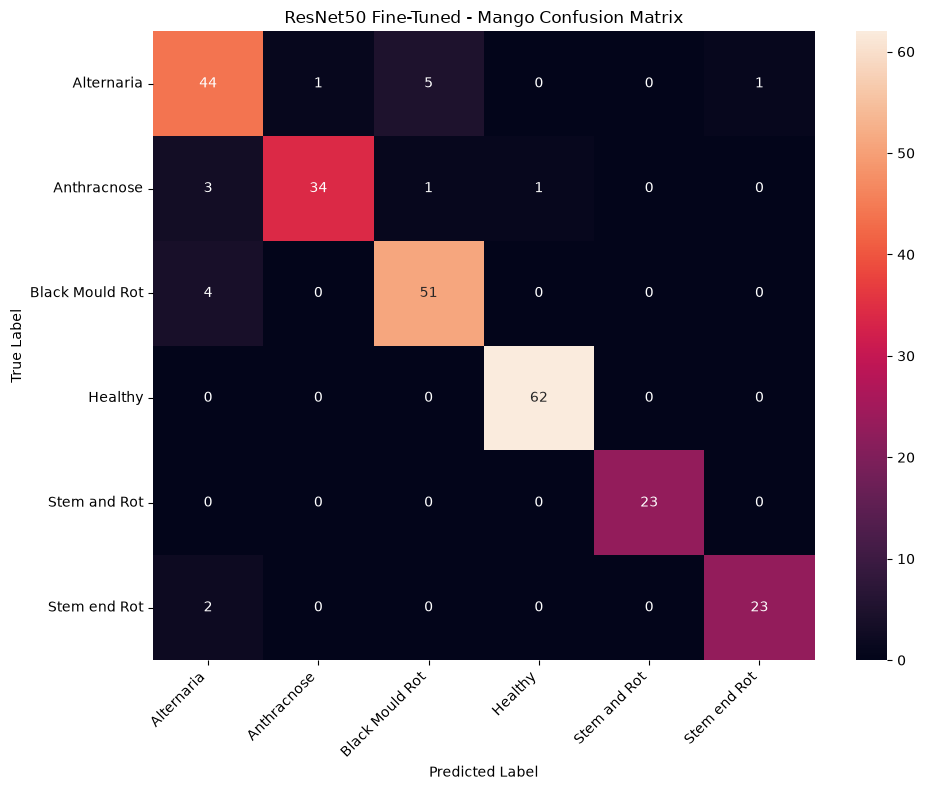

In [38]:
# RESNET50 FINE-TUNED - DETAILED EVALUATION

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_resnet_finetuned.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("=" * 60)
print("RESNET50 FINE-TUNED - CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Fine-Tuned - Mango Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

results = []

for class_name in class_names:
    results.append({
        "Dataset": DATASET_NAME,
        "Model": "ResNet50 Fine-Tuned",
        "Class": class_name,
        "Precision": report[class_name]["precision"],
        "Recall": report[class_name]["recall"],
        "F1_Score": report[class_name]["f1-score"],
        "Support": report[class_name]["support"]
    })

results.append({
    "Dataset": DATASET_NAME,
    "Model": "ResNet50 Fine-Tuned",
    "Class": "Overall Accuracy",
    "Precision": None,
    "Recall": None,
    "F1_Score": report["accuracy"],
    "Support": report["accuracy"]
})

results_df = pd.DataFrame(results)

results_df.to_csv(
    "../../reports/results/mango_resnet50_finetuned_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

NameError: name 'y_true' is not defined

In [1]:
# ============================================================
# RESNET50 - ALL REMAINING DISEASE DATASETS
# BASELINE + FINE-TUNING
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

BASELINE_EPOCHS = 20
FINETUNE_EPOCHS = 20

RANDOM_SEED = 42

DATASETS = [
    "Black Gram Leaf",
    "Coconut",
    "Watermelon",
    "apple",
    "coffee",
    "grapes",
    "jute",
    "maize",
    "orange",
    "pigonpea",
    "plant wild",
    "rice"
]

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path("../..")

METADATA_PATH = (
    PROJECT_ROOT /
    "reports" /
    "results" /
    "disease_final_metadata.csv"
)

MODEL_DIR = PROJECT_ROOT / "models" / "disease"

RESULT_DIR = PROJECT_ROOT / "reports" / "results"

CONFUSION_DIR = RESULT_DIR / "confusion_matrices"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD METADATA
# ============================================================

metadata = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata.shape)
print("Datasets:", metadata["Dataset"].unique())

# ============================================================
# IMAGE LOADING
# ============================================================

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


# ============================================================
# TF.DATA DATASET
# ============================================================

def create_dataset(dataframe, shuffle=False):

    paths = dataframe["Path"].values
    labels = dataframe["Label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ============================================================
# DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10)
    ],
    name="disease_data_augmentation"
)


# ============================================================
# BUILD RESNET50
# ============================================================

def build_resnet50(num_classes):

    base_model = ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        name="resnet50_base"
    )

    base_model.trainable = False

    inputs = layers.Input(
        shape=(224, 224, 3),
        name="image_input"
    )

    # Augmentation
    x = data_augmentation(inputs)

    # Convert [0,1] -> [0,255]
    x = layers.Rescaling(
        scale=255.0,
        name="rescaling"
    )(x)

    # ResNet50 preprocessing
    x = layers.Lambda(
        preprocess_input,
        name="resnet_preprocess"
    )(x)

    # ResNet50
    x = base_model(
        x,
        training=False
    )

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        0.3
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier"
    )(x)

    model = Model(
        inputs,
        outputs,
        name="ResNet50_Disease"
    )

    return model


# ============================================================
# RESULTS STORAGE
# ============================================================

summary_results = []


# ============================================================
# MAIN LOOP
# ============================================================

for dataset_name in DATASETS:

    print("\n")
    print("=" * 70)
    print(f"STARTING DATASET: {dataset_name}")
    print("=" * 70)

    start_time = time.time()

    try:

        # ----------------------------------------------------
        # SELECT DATASET
        # ----------------------------------------------------

        dataset_df = metadata[
            metadata["Dataset"] == dataset_name
        ].copy()

        if len(dataset_df) == 0:

            print(
                f"WARNING: No data found for {dataset_name}"
            )

            continue

        # ----------------------------------------------------
        # GET CLASS NAMES USING LABEL ORDER
        # ----------------------------------------------------

        label_map = (
            dataset_df[
                ["Label", "Class"]
            ]
            .drop_duplicates()
            .sort_values("Label")
        )

        class_names = label_map["Class"].tolist()

        num_classes = len(class_names)

        print(
            f"Number of classes: {num_classes}"
        )

        print(
            "Classes:",
            class_names
        )

        # ----------------------------------------------------
        # CHECK LABELS
        # ----------------------------------------------------

        expected_labels = np.arange(
            num_classes
        )

        actual_labels = np.sort(
            dataset_df["Label"].unique()
        )

        if not np.array_equal(
            actual_labels,
            expected_labels
        ):

            raise ValueError(
                f"Labels are not consecutive for "
                f"{dataset_name}. "
                f"Found: {actual_labels}"
            )

        # ----------------------------------------------------
        # TRAIN / VALIDATION / TEST
        # ----------------------------------------------------

        train_df = dataset_df[
            dataset_df["Split"] == "train"
        ].copy()

        val_df = dataset_df[
            dataset_df["Split"] == "val"
        ].copy()

        test_df = dataset_df[
            dataset_df["Split"] == "test"
        ].copy()

        print(
            f"Train: {len(train_df)}"
        )

        print(
            f"Validation: {len(val_df)}"
        )

        print(
            f"Test: {len(test_df)}"
        )

        # ----------------------------------------------------
        # CREATE TF DATASETS
        # ----------------------------------------------------

        train_ds = create_dataset(
            train_df,
            shuffle=True
        )

        val_ds = create_dataset(
            val_df,
            shuffle=False
        )

        test_ds = create_dataset(
            test_df,
            shuffle=False
        )

        # ====================================================
        # BUILD BASELINE MODEL
        # ====================================================

        model = build_resnet50(
            num_classes
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=1e-3
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        baseline_path = (
            MODEL_DIR /
            f"{dataset_name.replace(' ', '_').lower()}_resnet50_baseline.keras"
        )

        # ----------------------------------------------------
        # BASELINE CALLBACKS
        # ----------------------------------------------------

        baseline_callbacks = [

            ModelCheckpoint(
                filepath=str(baseline_path),
                monitor="val_accuracy",
                mode="max",
                save_best_only=True,
                verbose=1
            ),

            EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=4,
                restore_best_weights=True,
                verbose=1
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.2,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ]

        # ----------------------------------------------------
        # BASELINE TRAINING
        # ----------------------------------------------------

        print("\nStarting baseline training...")

        baseline_start = time.time()

        baseline_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=BASELINE_EPOCHS,
            callbacks=baseline_callbacks,
            verbose=1
        )

        baseline_time = time.time() - baseline_start

        # ====================================================
        # LOAD BEST BASELINE CHECKPOINT
        # ====================================================

        print("\nLoading BEST baseline checkpoint...")

        model = tf.keras.models.load_model(
            baseline_path,
            custom_objects={
                "preprocess_input": preprocess_input
            }
        )

        # ----------------------------------------------------
        # BASELINE TEST
        # ----------------------------------------------------

        baseline_loss, baseline_accuracy = model.evaluate(
            test_ds,
            verbose=1
        )

        print(
            f"\nBaseline Test Accuracy: "
            f"{baseline_accuracy:.4f}"
        )

        # ====================================================
        # FINE-TUNING
        # ====================================================

        print("\nStarting fine-tuning...")

        # Get ResNet50 base model from
        # the BEST baseline model
        resnet_base = model.get_layer(
            "resnet50_base"
        )

        resnet_base.trainable = True

        # Freeze all layers first
        for layer in resnet_base.layers:

            layer.trainable = False

        # Unfreeze last 30 layers
        for layer in resnet_base.layers[-30:]:

            layer.trainable = True

        # ----------------------------------------------------
        # RECOMPILE WITH SMALL LR
        # ----------------------------------------------------

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=1e-5
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        finetuned_path = (
            MODEL_DIR /
            f"{dataset_name.replace(' ', '_').lower()}_resnet50_finetuned.keras"
        )

        # ----------------------------------------------------
        # FINE-TUNING CALLBACKS
        # ----------------------------------------------------

        finetune_callbacks = [

            ModelCheckpoint(
                filepath=str(finetuned_path),
                monitor="val_accuracy",
                mode="max",
                save_best_only=True,
                verbose=1
            ),

            EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=4,
                restore_best_weights=True,
                verbose=1
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.2,
                patience=2,
                min_lr=1e-7,
                verbose=1
            )
        ]

        # ----------------------------------------------------
        # FINE-TUNING TRAINING
        # ----------------------------------------------------

        finetune_start = time.time()

        finetune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FINETUNE_EPOCHS,
            callbacks=finetune_callbacks,
            verbose=1
        )

        finetune_time = time.time() - finetune_start

        # ====================================================
        # LOAD BEST FINE-TUNED MODEL
        # ====================================================

        print("\nLoading BEST fine-tuned model...")

        best_model = tf.keras.models.load_model(
            finetuned_path,
            custom_objects={
                "preprocess_input": preprocess_input
            }
        )

        # ====================================================
        # FINAL TEST
        # ====================================================

        test_loss, test_accuracy = best_model.evaluate(
            test_ds,
            verbose=1
        )

        print(
            f"\nFine-Tuned Test Accuracy: "
            f"{test_accuracy:.4f}"
        )

        # ====================================================
        # PREDICTIONS
        # ====================================================

        y_true = []
        y_pred = []

        for images, labels in test_ds:

            predictions = best_model.predict(
                images,
                verbose=0
            )

            predicted_labels = np.argmax(
                predictions,
                axis=1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predicted_labels
            )

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # ====================================================
        # CLASSIFICATION REPORT
        # ====================================================

        report = classification_report(
            y_true,
            y_pred,
            labels=np.arange(num_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        # ====================================================
        # SAVE CLASS METRICS
        # ====================================================

        metrics_rows = []

        for class_name in class_names:

            metrics_rows.append({

                "Dataset": dataset_name,

                "Model": "ResNet50 Fine-Tuned",

                "Class": class_name,

                "Precision": report[class_name]["precision"],

                "Recall": report[class_name]["recall"],

                "F1_Score": report[class_name]["f1-score"],

                "Support": report[class_name]["support"]

            })

        metrics_rows.append({

            "Dataset": dataset_name,

            "Model": "ResNet50 Fine-Tuned",

            "Class": "Overall Accuracy",

            "Precision": None,

            "Recall": None,

            "F1_Score": report["accuracy"],

            "Support": report["accuracy"]

        })

        metrics_df = pd.DataFrame(
            metrics_rows
        )

        metrics_path = (
            RESULT_DIR /
            f"{dataset_name.replace(' ', '_').lower()}_resnet50_finetuned_metrics.csv"
        )

        metrics_df.to_csv(
            metrics_path,
            index=False
        )

        # ====================================================
        # CONFUSION MATRIX
        # ====================================================

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(num_classes)
        )

        plt.figure(
            figsize=(
                max(8, num_classes * 0.5),
                max(6, num_classes * 0.5)
            )
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )

        plt.title(
            f"ResNet50 Fine-Tuned - {dataset_name}"
        )

        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.tight_layout()

        cm_path = (
            CONFUSION_DIR /
            f"{dataset_name.replace(' ', '_').lower()}_resnet50_confusion_matrix.png"
        )

        plt.savefig(
            cm_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

        # ====================================================
        # SUMMARY
        # ====================================================

        total_time = time.time() - start_time

        summary_row = {

            "Dataset": dataset_name,

            "Num_Classes": num_classes,

            "Train_Size": len(train_df),

            "Validation_Size": len(val_df),

            "Test_Size": len(test_df),

            "Baseline_Accuracy": baseline_accuracy,

            "FineTuned_Accuracy": test_accuracy,

            "Macro_F1": report["macro avg"]["f1-score"],

            "Weighted_F1": report["weighted avg"]["f1-score"],

            "Baseline_Epochs": len(
                baseline_history.history["loss"]
            ),

            "FineTuning_Epochs": len(
                finetune_history.history["loss"]
            ),

            "Baseline_Time_Min": baseline_time / 60,

            "FineTuning_Time_Min": finetune_time / 60,

            "Total_Time_Min": total_time / 60
        }

        summary_results.append(
            summary_row
        )

        # ====================================================
        # SAVE SUMMARY AFTER EVERY DATASET
        # ====================================================

        summary_df = pd.DataFrame(
            summary_results
        )

        summary_path = (
            RESULT_DIR /
            "disease_resnet50_summary.csv"
        )

        summary_df.to_csv(
            summary_path,
            index=False
        )

        # ====================================================
        # PRINT RESULT
        # ====================================================

        print("\n" + "=" * 70)

        print(
            f"COMPLETED: {dataset_name}"
        )

        print(
            f"Baseline Accuracy: "
            f"{baseline_accuracy:.4f}"
        )

        print(
            f"Fine-Tuned Accuracy: "
            f"{test_accuracy:.4f}"
        )

        print(
            f"Macro F1: "
            f"{report['macro avg']['f1-score']:.4f}"
        )

        print(
            f"Weighted F1: "
            f"{report['weighted avg']['f1-score']:.4f}"
        )

        print(
            f"Time: "
            f"{total_time / 60:.2f} minutes"
        )

        print("=" * 70)

        # ====================================================
        # CLEAN MEMORY
        # ====================================================

        del model
        del best_model
        del train_ds
        del val_ds
        del test_ds

        tf.keras.backend.clear_session()

        gc.collect()

    except Exception as e:

        print("\n" + "!" * 70)

        print(
            f"ERROR in dataset: {dataset_name}"
        )

        print(
            f"Error: {e}"
        )

        print("Skipping this dataset...")

        print("!" * 70)

        tf.keras.backend.clear_session()

        gc.collect()

        continue


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n")
print("=" * 70)
print("ALL DATASETS COMPLETED")
print("=" * 70)

if len(summary_results) > 0:

    final_summary = pd.DataFrame(
        summary_results
    )

    print(
        final_summary[
            [
                "Dataset",
                "Baseline_Accuracy",
                "FineTuned_Accuracy",
                "Macro_F1",
                "Weighted_F1"
            ]
        ].to_string(index=False)
    )

    print(
        f"\nSummary saved to:\n"
        f"{RESULT_DIR / 'disease_resnet50_summary.csv'}"
    )

else:

    print("No datasets completed successfully.")

Metadata shape: (112380, 5)
Datasets: <ArrowStringArray>
[     'Watermelon',        'pigonpea',           'mango',           'maize',
            'jute',          'grapes',          'coffee',         'Coconut',
 'Black Gram Leaf',           'apple',      'plant wild',          'orange',
            'rice']
Length: 13, dtype: str


STARTING DATASET: Black Gram Leaf
Number of classes: 5
Classes: ['Cercospora leaf spot', 'Healthy', 'Insect', 'Leaf Crinkle', 'Yellow Mosaic']
Train: 2826
Validation: 606
Test: 606


Starting baseline training...
Epoch 1/20


c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7771 - loss: 0.6143
Epoch 1: val_accuracy improved from None to 0.92079, saving model to ..\..\models\disease\black_gram_leaf_resnet50_baseline.keras

Epoch 1: finished saving model to ..\..\models\disease\black_gram_leaf_resnet50_baseline.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7771 - loss: 0.6143 - val_accuracy: 0.9208 - val_loss: 0.2500 - learning_rate: 0.0010
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.9207 - loss: 0.2538
Epoch 2: val_accuracy improved from 0.92079 to 0.94224, saving model to ..\..\models\disease\black_gram_leaf_resnet50_baseline.keras

Epoch 2: finished saving model to ..\..\models\disease\black_gram_leaf_resnet50_baseline.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9207 - loss: 0.2538 - val_accuracy: 0.9422 - val_loss: 0.1720 - learning_rate: 0.0010
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.9423 - loss: 0.1875
Epoch 3: val_accuracy

c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.8948 - loss: 0.2911
Epoch 1: val_accuracy improved from None to 0.95747, saving model to ..\..\models\disease\coconut_resnet50_baseline.keras

Epoch 1: finished saving model to ..\..\models\disease\coconut_resnet50_baseline.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8948 - loss: 0.2911 - val_accuracy: 0.9575 - val_loss: 0.1173 - learning_rate: 0.0010
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9726 - loss: 0.0909
Epoch 2: val_accuracy improved from 0.95747 to 0.97471, saving model to ..\..\models\disease\coconut_resnet50_baseline.keras

Epoch 2: finished saving model to ..\..\models\disease\coconut_resnet50_baseline.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9726 - loss: 0.0909 - val_accuracy: 0.9747 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.9800 - loss: 0.0677
Epoch 3: val_accuracy improved from 0.97

...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.5228 - loss: 1.1388
Epoch 1: val_accuracy improved from None to 0.72603, saving model to ..\..\models\disease\pigonpea_resnet50_baseline.keras

Epoch 1: finished saving model to ..\..\models\disease\pigonpea_resnet50_baseline.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5228 - loss: 1.1388 - val_accuracy: 0.7260 - val_loss: 0.7015 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.6887 - loss: 0.7308
Epoch 2: val_accuracy improved from 0.72603 to 0.76712, saving model to ..\..\models\disease\pigonpea_resnet50_baseline.keras

Epoch 2: finished saving model to ..\..\models\disease\pigonpea_resnet50_baseline.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6887 - loss: 0.7308 - val_accuracy: 0.7671 - val_loss: 0.5608 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.7783 - loss: 0.5611
Epoch 3: val_accuracy improved from 0.76712 to 0

c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.2761 - loss: 3.0441
Epoch 1: val_accuracy improved from None to 0.43665, saving model to ..\..\models\disease\plant_wild_resnet50_baseline.keras

Epoch 1: finished saving model to ..\..\models\disease\plant_wild_resnet50_baseline.keras
408/408 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.2761 - loss: 3.0441 - val_accuracy: 0.4367 - val_loss: 2.1928 - learning_rate: 0.0010
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4474 - loss: 2.1033
Epoch 2: val_accuracy improved from 0.43665 to 0.49152, saving model to ..\..\models\disease\plant_wild_resnet50_baseline.keras

Epoch 2: finished saving model to ..\..\models\disease\plant_wild_resnet50_baseline.keras
408/408 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.4474 - loss: 2.1033 - val_accuracy: 0.4915 - val_loss: 1.9682 - learning_rate: 0.0010
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5028 - loss: 1.8409
Epoch 3: val_accuracy improved fro

c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3525 - loss: 1.5011
Epoch 1: val_accuracy improved from None to 0.47154, saving model to ..\..\models\disease\rice_resnet50_baseline.keras

Epoch 1: finished saving model to ..\..\models\disease\rice_resnet50_baseline.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3525 - loss: 1.5011 - val_accuracy: 0.4715 - val_loss: 1.2307 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4625 - loss: 1.2147
Epoch 2: val_accuracy improved from 0.47154 to 0.51829, saving model to ..\..\models\disease\rice_resnet50_baseline.keras

Epoch 2: finished saving model to ..\..\models\disease\rice_resnet50_baseline.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4625 - loss: 1.2147 - val_accuracy: 0.5183 - val_loss: 1.1057 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5044 - loss: 1.1405
Epoch 3: val_accuracy did not improve from 0.51829
50/50 ━━━━━━━━━━━━━━━━